# Assignment 4

Written by Kira Damo Due March 16th

# Part 1

## Question 1A

### Loading the modules and datasets

In [1]:
import pandas as pd
import numpy as np

In [2]:
from itemBasedRec import euclidSim, pearsonSim, cosineSim, standEst, svdEst, recommend, cross_validate_user, test, load_jokes, get_joke_text

In [3]:
ratings = pd.read_csv('/Users/kiradamo/Documents/DSC 478/jokes/modified_jester_data.csv', header=None)
jokes = pd.read_csv('/Users/kiradamo/Documents/DSC 478/jokes/jokes.csv', header=None)

In [4]:
jokes

,0,1
0,0,"A man visits the doctor. The doctor says ""I ha..."
1,1,This couple had an excellent relationship goin...
2,2,Q. What's 200 feet long and has 4 teeth? A. Th...
3,3,Q. What's the difference between a man and a t...
4,4,Q. What's O. J. Simpson's Internet address? A....
...,...,...
95,95,Two attorneys went into a diner and ordered tw...
96,96,A teacher is explaining to her class how diffe...
97,97,Age and Womanhood1. Between the ages of 13 and...
98,98,A bus station is where a bus stops.A train sta...


In [5]:
ratings

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3.18,19.79,1.34,2.84,3.48,2.50,1.15,15.17,2.02,6.24,...,13.82,0.00,0.00,0.00,0.00,0.00,5.37,0.00,0.00,0.00
1,15.08,10.71,17.36,15.37,8.62,1.34,10.27,5.66,19.88,20.22,...,13.82,6.05,10.71,18.86,10.81,8.86,14.06,11.34,6.68,12.07
2,0.00,0.00,0.00,0.00,20.03,20.27,20.03,20.27,0.00,0.00,...,0.00,0.00,0.00,20.08,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,19.35,0.00,0.00,12.80,19.16,8.18,17.21,0.00,12.84,...,0.00,0.00,0.00,11.53,0.00,0.00,0.00,0.00,0.00,0.00
4,19.50,15.61,6.83,5.61,12.36,12.60,18.04,15.61,10.56,16.73,...,16.19,16.58,15.27,16.19,16.73,12.55,14.11,17.55,12.80,12.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12.94,5.47,16.19,5.51,6.92,8.48,14.20,14.83,4.98,13.96,...,6.58,9.93,15.37,7.89,13.72,6.87,13.23,5.47,14.54,13.38
996,15.27,11.39,16.39,5.37,7.41,16.58,12.17,2.84,5.13,4.30,...,0.00,0.00,0.00,0.00,6.58,0.00,0.00,0.00,0.00,0.00
997,16.58,16.63,15.85,7.89,14.40,9.74,14.54,13.14,6.34,11.78,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
998,3.67,4.45,3.67,3.67,9.40,7.65,3.86,4.40,3.67,4.93,...,3.82,6.87,6.87,3.77,3.77,3.77,3.77,3.77,3.77,3.28


In [6]:
dataMat = np.array(ratings)

In [7]:
recs = recommend(dataMat, user=117, N=5, simMeas=pearsonSim, estMethod=standEst)
for joke_id, rating in sorted(recs, reverse=True):
    print(f'Joke: {joke_id}, Predicted Rating: {rating:.2f}')
    print(jokes.iloc[joke_id][1], '\n')

Joke: 99, Predicted Rating: 10.61
Q: What's the difference between greeting a Queen and greeting thePresident of the United  States?A: You only have to get on one knee to greet the queen. 

Joke: 97, Predicted Rating: 10.61
Age and Womanhood1. Between the ages of 13 and 18 ... She is like Africa virgin and unexplored. 2. Between the ages of 19 and 35 ... She is like Asia hot and exotic. 3. Between the ages of 36 and 45 ... She is like America fully explored breathtakingly beautiful and free with her resources.4. Between the ages of 46 and 56 ...She is like Europe exhausted but still has points of interest. 5. After 56 she is like Australia ...Everybody knows it's down there but who gives a damn? 

Joke: 92, Predicted Rating: 10.59
Reaching the end of a job interview the human resources person asked a young engineer fresh out of Stanford"And what starting salary were you looking for?"The engineer said "In the neighborhood of $125000 a year depending on the benefits package."The intervie

In [8]:
recs = recommend(dataMat, user=117, N=5, simMeas=cosineSim, estMethod=standEst)
for joke_id, rating in sorted(recs, reverse=True):
    print(f'Joke: {joke_id}, Predicted Rating: {rating:.2f}')
    print(jokes.iloc[joke_id][1], '\n')

Joke: 99, Predicted Rating: 10.57
Q: What's the difference between greeting a Queen and greeting thePresident of the United  States?A: You only have to get on one knee to greet the queen. 

Joke: 97, Predicted Rating: 10.57
Age and Womanhood1. Between the ages of 13 and 18 ... She is like Africa virgin and unexplored. 2. Between the ages of 19 and 35 ... She is like Asia hot and exotic. 3. Between the ages of 36 and 45 ... She is like America fully explored breathtakingly beautiful and free with her resources.4. Between the ages of 46 and 56 ...She is like Europe exhausted but still has points of interest. 5. After 56 she is like Australia ...Everybody knows it's down there but who gives a damn? 

Joke: 92, Predicted Rating: 10.57
Reaching the end of a job interview the human resources person asked a young engineer fresh out of Stanford"And what starting salary were you looking for?"The engineer said "In the neighborhood of $125000 a year depending on the benefits package."The intervie

In [9]:
recs = recommend(dataMat, user=441, N=5, simMeas=pearsonSim, estMethod=standEst)
for joke_id, rating in sorted(recs, reverse=True):
    print(f'Joke: {joke_id}, Predicted Rating: {rating:.2f}')
    print(jokes.iloc[joke_id][1], '\n')

Joke: 99, Predicted Rating: 13.95
Q: What's the difference between greeting a Queen and greeting thePresident of the United  States?A: You only have to get on one knee to greet the queen. 

Joke: 88, Predicted Rating: 13.91
A radio conversation of a US naval ship with Canadian authorities ... Americans: Please divert your course 15 degrees to the North to avoid a collision.Canadians: Recommend you divert YOUR course 15 degrees to the South to avoid a collision.Americans: This is the Captain of a US Navy ship.  I say again divert YOUR course.Canadians: No.  I say again you divert YOUR course.Americans: This is the aircraft carrier USS LINCOLN the second largest ship in the United States' Atlantic Fleet. We are accompanied by three destroyers three cruisers and numerous support vessels. I demand that you change your course 15 degrees north that's ONE FIVE DEGREES NORTH or counter-measures will be undertaken to ensure the safety of this ship.Canadians: This is a lighthouse.  Your call. 



In [10]:
recs = recommend(dataMat, user=441, N=5, simMeas=pearsonSim, estMethod=svdEst)
for joke_id, rating in sorted(recs, reverse=True):
    print(f'Joke: {joke_id}, Predicted Rating: {rating:.2f}')
    print(jokes.iloc[joke_id][1], '\n')

Joke: 69, Predicted Rating: 14.10
Employer to applicant: "In this job we need someone who is responsible."Applicant: "I'm the one you want. On my last job every time anything went wrong they said I was responsible." 

Joke: 50, Predicted Rating: 14.14
Did you hear that Clinton has announced there is a new national bird?  The spread eagle. 

Joke: 45, Predicted Rating: 14.30
A couple has been married for 75 years. For the husband's 95thbirthday his wife decides to surprise him by hiring a prostitute.That day the doorbell rings. The husband uses his walker to get to the door and opens it. A 21-year-old in a latex outfit smiles and says "Hi I here to give you super sex!" The old man says "I'll take the soup." 

Joke: 10, Predicted Rating: 14.14
Q. What do a hurricane a tornado and a redneck divorce all have in common? A. Someone's going to lose their trailer... 

Joke: 5, Predicted Rating: 14.23
Bill & Hillary are on a trip back to Arkansas. They're almost out of gas so Bill pulls into a 

## Question 1B

In [49]:
def test(dataMat, test_ratio, estMethod, simMeas=pearsonSim):
    # Write this function to iterate over all users and for each perform evaluation by calling
	# the above cross_validate_user function on each user. MAE will be the ratio of total error 
	# across all test cases to the total number of test cases, across all users

    #initializing variables
    total_error = 0
    num_errors = 0
    num_users = dataMat.shape[0]

    for user in range(num_users):
        error, n_errors = cross_validate_user(dataMat, user, test_ratio = 0.2, estMethod=standEst, simMeas=pearsonSim)

        total_error += error
        num_errors += n_errors

    MAE = total_error / num_errors
	
    return MAE


In [12]:
mae_stand = test(dataMat, test_ratio=0.2, estMethod=standEst, simMeas=pearsonSim)
mae_svd = test(dataMat, test_ratio=0.2, estMethod=svdEst, simMeas=pearsonSim)
print(f'Standard MAE: {mae_stand}')
print(f'SVD MAE: {mae_svd}')

Standard MAE: 3.6770657399504834
SVD MAE: 3.6927474164928547


The MAE of both methods is ~3.7.

## Question 1C

In [52]:
def print_most_similar_jokes(dataMat, joke_id, k, simMeas):
    sims = []
    num_jokes = dataMat.shape[1]
    for j in range(num_jokes):
        if j == joke_id:
            continue
        sim = simMeas(dataMat[:,joke_id], dataMat[:,j])
        sims.append((sim, j))
        
    #decreasing order
    sims.sort(reverse=True)

    print('Selected Joke:')
    print(jokes.iloc[joke_id][1], '\n')

    print(f'Top {k} Recommended Jokes are:')
    for sim, j in sims[:k]:
        print(f'Joke {j}, Similarity: {sim:.2f}')
        print(jokes.iloc[j][1], '\n')

In [50]:
#most similar jokes with Pearson similarity
print_most_similar_jokes(dataMat, 9, 3, pearsonSim)

Selected Joke:
Two cannibals are eating a clown one turns to other and says: "Does this taste funny to you?  

Top 3 Recommended Jokes are:
Joke 21, Similarity: 0.76
A duck walks into a pharmacy and asks for a condom. The pharmacist says"Would you like me to stick that on your bill?"The duck says: "What kind of duck do you think I am!" 

Joke 10, Similarity: 0.76
Q. What do a hurricane a tornado and a redneck divorce all have in common? A. Someone's going to lose their trailer... 

Joke 54, Similarity: 0.75
A woman has twins and gives them up for adoption.  One of them goes to a family in Egypt and is named "Amal."  The other goes to a  family in Spain; they name him "Juan."  Years later Juan sends a picture of himself to his mom.  Upon receiving the picture she tells her husband that she wishes she also had a picture of Amal.  Her husband responds "But they are twins-if you've seen Juan you've seen   Amal. 



In [51]:
#most similar jokes with Cosine similarity
print_most_similar_jokes(dataMat, 9, 3, cosineSim)

Selected Joke:
Two cannibals are eating a clown one turns to other and says: "Does this taste funny to you?  

Top 3 Recommended Jokes are:
Joke 10, Similarity: 0.93
Q. What do a hurricane a tornado and a redneck divorce all have in common? A. Someone's going to lose their trailer... 

Joke 37, Similarity: 0.93
May I take your order? the waiter asked. "Yes how do you prepare your chickens?" "Nothing special sir" he replied. "We just tell them straight out that they're going to die." 

Joke 21, Similarity: 0.93
A duck walks into a pharmacy and asks for a condom. The pharmacist says"Would you like me to stick that on your bill?"The duck says: "What kind of duck do you think I am!" 



## Question 1D

In [53]:
def training_sim(dataMat, simMeas):
    #computes similarity matrix
    num_items = dataMat.shape[1]
    simMat = np.zeros((num_items, num_items))
    for i in range(num_items):
        for j in range(num_items):
            if i != j:
                simMat[i,j]=simMeas(dataMat[:,i],dataMat[:,j])
    return simMat

In [17]:
def predict(dataMat, user, item, simMat, k):
    user_ratings = dataMat[user]
    sims = []
    for j in range(len(user_ratings)):
        if user_ratings[j] > 0 and j != item:
            sims.append((simMat[item, j], user_ratings[j]))
    sims.sort(reverse=True)

    sims = sims[:k]

    numerator = 0
    denominator = 0

    for sim, rating in sims:
        numerator += sim * rating
        denominator += abs(sim)

    if denominator == 0:
        return 0

    return numerator / denominator

In [54]:
p_mat = training_sim(dataMat, pearsonSim) #pearson similarity matrix
c_mat = training_sim(dataMat, cosineSim) #cosine similarity matrix

In [19]:
top_recs = recommend(dataMat, user=117, N=10, simMeas=pearsonSim, estMethod=standEst)[:2]
print(type(top_recs))

<class 'list'>


In [55]:
top_recs = recommend(dataMat, user=117, N=10, simMeas=pearsonSim, estMethod=standEst)[:2]
#top recommendations and their predicted ratings
for item, rating in top_recs:
    item = int(item)
    top2 = top_recs[:2]
    pred = predict(dataMat, 117, item, c_mat, k=10)
    print("Item:", item, "Predicted rating:", pred)

Item: 97 Predicted rating: 9.755648523941815
Item: 99 Predicted rating: 9.622120854365011


# Part 2

## Question 2A

### Loading the modules and data

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [22]:
X = pd.read_csv('/Users/kiradamo/Documents/DSC 478/segmentation_data/segmentation_data.txt', header=None)
y = np.loadtxt('/Users/kiradamo/Documents/DSC 478/segmentation_data/segmentation_classes.txt', delimiter="\t", usecols=1, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=99)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
print("Feature matrix:", X.shape)
print("Labels:", y.shape)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Feature matrix: (2100, 19)
Labels: (2100,)
Train size: (1680, 19)
Test size: (420, 19)


## Question 2B

In [25]:
pca = PCA()
pca.fit(X_train_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [26]:
pca95 = PCA(n_components=0.95)
X_reduced = pca95.fit_transform(X_train_scaled)
print("Number of components:", pca95.n_components_)

Number of components: 10


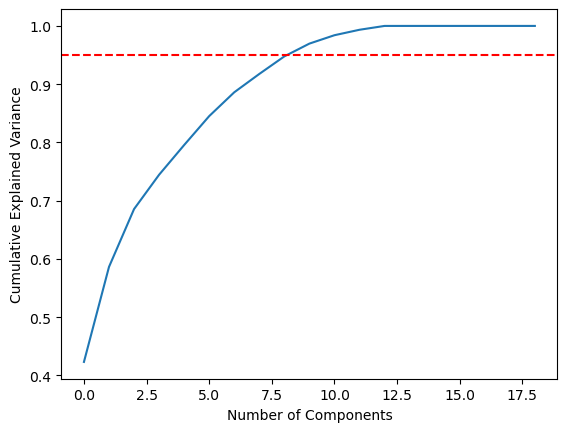

In [27]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--') # 95% threshold
plt.show()

The number does not correspond to the line entirely BUT the number of components is supposed be around where the line's "elbow is". 

## Question 2C

Creating model using the n components from part b and with required parameters.

In [29]:
rf = RandomForestClassifier(n_estimators=10, random_state=33)
scaler2 = StandardScaler()
pca2 = PCA(n_components = 10)

One pipeline uses PCA and the other does not:

In [30]:
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=10, random_state=33))
])

pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),  # r components
    ('rf', RandomForestClassifier(n_estimators=10, random_state=33))
])

In [31]:
pipeline1.fit(X_train, y_train)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [32]:
pipeline2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'


## Question 2D

In [33]:
train_acc1 = pipeline1.score(X_train, y_train)
train_acc2 = pipeline2.score(X_train, y_train)

print("Training accuracy (no PCA):", train_acc1)
print("Training accuracy (with PCA):", train_acc2)

Training accuracy (no PCA): 0.9988095238095238
Training accuracy (with PCA): 0.9988095238095238


In [34]:
cv_scores1 = cross_val_score(pipeline1, X_train, y_train, cv=10)
cv_scores2 = cross_val_score(pipeline2, X_train, y_train, cv=10)

print("CV accuracy (no PCA):", cv_scores1.mean())
print("CV accuracy (with PCA):", cv_scores2.mean())

CV accuracy (no PCA): 0.9684523809523808
CV accuracy (with PCA): 0.9244047619047618


Both models perform well on training and unseen data. The accuracy on the non-PCA model is slightly better.

## Question 2E

In [48]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)), #r from part b
    ('rf', RandomForestClassifier(random_state=77))
])

In [36]:
param_grid = {
    'rf__n_estimators': list(range(1,201,5)),
    'rf__max_depth': [1,5,10,15,20,25],
    'rf__min_samples_split': [2,3,4,5]
}

Searching for the best parameters and the best score of all the parameters in the grid:

In [37]:
grid = GridSearchCV(pipe, param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'rf__max_depth': 15, 'rf__min_samples_split': 2, 'rf__n_estimators': 41}
Best CV Accuracy: 0.9422619047619047


Random Forest with best parameters:

In [38]:
best_rf = RandomForestClassifier(
    n_estimators=41,
    max_depth=15,
    min_samples_split=2,
    random_state=77
)

In [40]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),   # r from part b
    ('rf', best_rf)
])

In [41]:
final_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'


In [42]:
train_accuracy = final_pipeline.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [43]:
test_accuracy = final_pipeline.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9380952380952381


In [47]:
print("Training Accuracy:", final_pipeline.score(X_train, y_train))
print("Test Accuracy:", final_pipeline.score(X_test, y_test))
print("Best CV Accuracy:", grid.best_score_)

Training Accuracy: 1.0
Test Accuracy: 0.9380952380952381
Best CV Accuracy: 0.9422619047619047


The training accuracy of 1.0 indicates that the pipeline model fits the training data perfectly and performs well on the test/unseen data. Although the accuracy shows 1.0, the accuracy on the test data is also almost 1.0 showing that overfitting is not occuring.